# Exercice de classifaction HAS - Baptiste Granier

_____

# Partie 1 : Ensemble des prétraiments généraux

_____
## 1.1. Import des bibliotèques

In [1]:
# Imports de traitements généraux et de visualisations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

# Import de bibliotèques de traitements de chaînes de caractères
import string
import re
import nltk
from nltk.corpus import stopwords

# Import de la bibliothèques Scikit-Learn
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

# Import du classifier XGBoost
from xgboost import XGBClassifier

# Import Deep Learning - Torch - models
import torch
from transformers import AutoTokenizer, AutoModel

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2. Définition des fonctions du notebook

### a. Défintintion des fonctions de nettoyage du texte

#### i. Fonction pour l'apprentissage type Bag of Words

In [2]:
# Définition des différentes tables de ponctuations et de mots à supprimer (liste réalisée empiriquement)
punc = string.punctuation + "\n\r\t"
trans_table = str.maketrans(punc, " " * len(punc))
a_enlever = ["simple html", "markdown", "xa0", "simple_html", '"}', "'{\'simple_html\':", '\\']

def clean_text(x, a_enlever=a_enlever, test_punc = True, test_case = True):
    # Si aucune valeur n'est à modifier, renvoie x
    if not isinstance(x, str):
        return x
    # Suppressions des séparateurs insécables
    x = x.replace("\xa0", " ")
    # retrait des balises
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"\\[rnt]", " ", x)
    # Table de retrait de la ponctuation
    if test_punc == True : 
        x = x.translate(trans_table)
    # Retrait de la case (Majuscules vs minuscules)
    if test_case == True : 
        x = x.casefold()
    # Parcours de la liste des mots à supprimer
    for mot in a_enlever:
        x = x.replace(mot, " ")
    # Retrait des multiples espaces entre les mots
    x = " ".join(x.split())
    return x

#### i. Fonction pour l'apprentissage des embeddings d'un LLM type Bert

In [3]:
def clean_text_bert(x, a_enlever=a_enlever):
    # Si aucune valeur n'est à modifier, renvoie x
    if not isinstance(x, str):
        return x
    # Suppressions des séparateurs insécables
    x = x.replace("\xa0", " ")
    # retrait des balises
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"\\[rnt]", " ", x)
    # Parcours de la liste des mots à supprimer
    for mot in a_enlever:
        x = x.replace(mot, " ")
    # Retrait des multiples espaces entre les mots
    x = " ".join(x.split())
    return x

### b. Défintion de la fonction de fit et d'évaluation de modèles de classification

In [4]:
def fit_et_evaluation_data_test(model, X_train, X_test, y_train, y_test):
    # Ajustement du modèle avec les données d'apprentissage 
    model.fit(X_train, y_train)
    # Prédictions à partir des données de tests
    predict_model = model.predict(X_test)
    # Affichage des valeurs
    print("_____________________________________________")
    print('Essai sur echantillon de test')
    # Calcul du F1 - Score
    print(f"F1 macro : {f1_score(y_test, predict_model, average="macro"):.4f}")
    # Calcul du score
    print(f"Score : {model.score(X_test, y_test):.4f}")
    # Calcul de la matrice de confusion
    confusion = confusion_matrix(y_test, predict_model)
    #print("_______\nClassification report")
    print(classification_report(y_test, predict_model))
    # print("_______\nConfusion matrice")

    # print(confusion)
    # Affichage de la matrice de confusion
    disp = ConfusionMatrixDisplay(confusion)
    disp.plot()
    plt.show()

### c. Fonction de comptage des valeurs cibles avec leur labels associés

In [5]:
def extract_labels_counts(df, colonne):
    # Extraction des valeurs de compte du tableau
    counts = df[colonne].value_counts().sort_index(key=lambda x: x.str.casefold())
    # Extraction des labels
    labels = counts.index.to_numpy()
    # Passage en numpy
    counts = counts.values

    return labels, counts 

### d. Fonction d'affichage des labels par ordre décroissant 

In [6]:
def plot_classes(labels, counts):
    order = np.argsort(counts)[::-1]
    labels = labels[order]
    counts = counts[order]
    plt.figure(figsize=(15, 6))
    plt.bar(labels, counts)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Nombre d'exemples")
    plt.title("Distribution des classes")
    plt.tight_layout()
    plt.grid(True, alpha = 0.3)
    plt.yscale("log")
    plt.show()

### e. Fonction d'affichage des embeddings via UMAP

In [7]:
def plot_umap_3D(X_emb, y_train):
    # Définition de l'ensemble de représentation (3D ici)
    reducer = umap.UMAP(
        n_components=3,
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
    # Ajustement et transformation de la représentation
    X_umap_3d = reducer.fit_transform(X_emb)

    # Encodage des variables cibles pour l'affichage de la légende
    le_b = LabelEncoder()
    y_plot = le_b.fit_transform(y_train)

    # Création de la figure
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Affichage des points
    sc = ax.scatter(
        X_umap_3d[:, 0],
        X_umap_3d[:, 1],
        X_umap_3d[:, 2],
        c=y_plot,
        cmap="tab20",
        alpha=0.7,
        s=20
    )

    # Définition des légendes
    handles, _ = sc.legend_elements(num=len(le_b.classes_))
    labels = le_b.classes_

    # Affichage des titres et des légendes
    ax.legend(
        handles,
        labels,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    ax.set_title("UMAP 3D des embeddings CamemBERT")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_zlabel("UMAP-3")

    plt.show()

## f. Fonction de Validation croisée

In [ ]:
def crossvalidation_multi(model, X, y, n_splits=5, random_state=42):
    # Définition du nombre de plis de stratification
    cv = StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=random_state)
    # Définition des dictionnaires de sorties
    scoring = {"f1_macro": "f1_macro", "f1_micro": "f1_micro","accuracy": "accuracy"}
    # Calcul de la validation croisée
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    # Affichage des résultats
    for k in scoring:
        mean = res[f"test_{k}"].mean()
        std  = res[f"test_{k}"].std()
        print(f"{k:>10}: {mean:.3f} ± {std:.3f}")

    return res

## 1.3. Import des fichiers

#### a. Import du jeu de données

Nous importons ici le fichier de données ainsi que le fichier contenant l'arborescence de l'ensemble des catégories du jeu de données.

In [9]:
# Chemin d'accès du fichier
data_file = "data/has-publications-single/csv/AllPublications.csv"
# Import via fonction pandas
data_df = pd.read_csv(data_file, sep = ",")
# Afficahge des propriétés
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16325 entries, 0 to 16324
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   class                  16325 non-null  object
 1   id                     16316 non-null  object
 2   title                  16314 non-null  object
 3   documentLinkSet        16304 non-null  object
 4   creationDate           16304 non-null  object
 5   publicationDate        16291 non-null  object
 6   categoriesThematiques  16292 non-null  object
 7   liensSiteWeb           3976 non-null   object
 8   resumeSiteWeb          7728 non-null   object
 9   pageURL                16304 non-null  object
 10  md5                    16292 non-null  object
 11  apiAccessDate          16292 non-null  object
dtypes: object(12)
memory usage: 1.5+ MB


#### b. Import du fichier de documentation

In [10]:
# Chemin d'accès du fichier
documentation_file = "documentation/categories_thematiques.csv"
# Import via fonction pandas
docu_df = pd.read_csv(documentation_file, sep = ";")
# Afficahge des propriétés
docu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         205 non-null    object
 1   Nom        205 non-null    object
 2   Parent     205 non-null    object
 3   Parent-ID  205 non-null    object
 4   Synonymes  65 non-null     object
 5   Ordre      205 non-null    int64 
 6   Nb. fils   205 non-null    int64 
 7   Nb. desc.  205 non-null    int64 
 8   Nb. Pub.   205 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 14.5+ KB


## 1.4. Séléction des classes d'intérêt

### a. Sélection des classes à partir des données de l'arborescence

Il s'agit de récupérer ici l'ensemble des classes dont le parent est la classe "Maladies et états de santé".

In [11]:
# Création du masque
Maladies_df = docu_df[docu_df["Parent"]=="Maladies et états de santé"]
# Nombre de classes
print(f'Nombre de classe: {len(Maladies_df)}')
# Affichage du dataframe
Maladies_df

Nombre de classe: 26


,ID,Nom,Parent,Parent-ID,Synonymes,Ordre,Nb. fils,Nb. desc.,Nb. Pub.
2,c_64656,Douleur - Inflammation,Maladies et états de santé,c_64654,Douleur ? Inflammation\r\nInflammation - Douleur,0,0,0,1146
3,c_64657,Système immunitaire,Maladies et états de santé,c_64654,NaN,0,4,4,1145
8,c_64663,C?ur,Maladies et états de santé,c_64654,NaN,0,7,7,1592
11,c_64668,Bouche et dents,Maladies et états de santé,c_64654,NaN,0,4,4,209
12,c_64669,Peau et tissu conjonctif,Maladies et états de santé,c_64654,NaN,0,1,1,1220
14,c_64671,Métabolisme et système endocrinien,Maladies et états de santé,c_64654,NaN,0,6,6,1284
15,c_64672,Appareil digestif,Maladies et états de santé,c_64654,NaN,0,5,5,1487
18,c_64675,Sang et lymphe,Maladies et états de santé,c_64654,NaN,0,6,6,943
21,c_64678,"Maladies génétiques, rares, congénitales",Maladies et états de santé,c_64654,NaN,0,0,0,902
22,c_64679,Infections,Maladies et états de santé,c_64654,NaN,0,6,6,2151


### b. Traitements du nom des classes afin de lever les ambiguïtés

In [12]:
# Remplacement des mots mal encodé en UTF-8
Maladies_df["Nom"] = Maladies_df["Nom"].replace({"C?ur": "Cœur","?il": "Œil"})
# Extraction des valeurs
vec_classes = Maladies_df["Nom"].values
# Tri des valeurs
vec_classes = sorted(vec_classes, key=str.lower)
# Affichage des objets et des  proriétés
print(vec_classes)
print(f'Nombre de classe: {len(Maladies_df)}')

['Appareil digestif', 'Appareil génital', 'Appareil locomoteur', 'Appareil respiratoire', 'Bouche et dents', 'Cancers - divers', 'Cœur', 'Douleur - Inflammation', 'Grossesse et reproduction', 'Handicap', 'Infections', 'Intoxications - Iatrogénie', 'Maladies génétiques, rares, congénitales', 'Métabolisme et système endocrinien', 'ORL', 'Peau et tissu conjonctif', 'Perte d?autonomie', 'Perte de conscience', 'Sang et lymphe', 'Sein', 'Système immunitaire', 'Système nerveux', 'Système urinaire', 'Troubles mentaux et comportementaux', 'Vaisseaux sanguins', 'Œil']
Nombre de classe: 26


C:\Users\grani\AppData\Local\Temp\ipykernel_37688\544433458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Maladies_df["Nom"] = Maladies_df["Nom"].replace({"C?ur": "Cœur","?il": "Œil"})


### c. Application du masquage au jeu de données et sélection des observations

In [13]:
# Affichage de l'entête
data_df.head()

,class,id,title,documentLinkSet,creationDate,publicationDate,categoriesThematiques,liensSiteWeb,resumeSiteWeb,pageURL,md5,apiAccessDate
0,GuideMethodologique,p_3318028,Grille descriptive des fonctionnalités des dis...,"[{'id': 'c_419016', 'title': 'Guide pour le dé...",2022-02-17T14:53:03Z,2020-10-14T11:44:00Z,"['Méthodologie', 'c_2051449', 'E-santé', 'Disp...","[{'class': 'ArticleWYSIWYG', 'id': 'c_928541',...","{'simple_html': ""<div><p>La HAS a publié une g...",https://www.has-sante.fr/jcms/p_3318028/,9238bbd505dd680f26ff942460fd71b5,2022-05-02T05:10:16+00:00
1,GuideMethodologique,p_3316447,Rencontres d’orientation stratégique avec la H...,"[{'id': 'p_3317279', 'title': 'Modalités de so...",2022-02-10T13:48:47Z,2022-02-15T13:55:00Z,"['Méthodologie', ""Comprendre l'évaluation des ...","[{'class': 'ArticleWYSIWYG', 'id': 'c_2821948'...","{'simple_html': ""<div><p>Afin d’accompagner le...",https://www.has-sante.fr/jcms/p_3316447/,da558fc502468e73f5c085c17a4c44d6,2022-05-02T05:10:16+00:00
2,GuideMethodologique,p_3312383,Actualisation des recommandations - Note de ca...,"[{'id': 'p_3312386', 'title': 'Actualisation d...",2022-01-27T14:44:45Z,2022-01-27T16:39:19Z,"['Méthodologie', 'Toutes nos publications par ...",NaN,{'simple_html': '<div><p>Les recommandations d...,https://www.has-sante.fr/jcms/p_3312383/,936065f183b7bb6401b83c9a27dc2b1d,2022-05-02T05:10:16+00:00
3,GuideMethodologique,p_3293982,Certification des Prestataires de Services et ...,"[{'id': 'p_3293539', 'title': 'Certification d...",2021-10-21T06:59:49Z,2021-10-21T07:50:13Z,"['Aides techniques', 'Qualité et sécurité des ...",NaN,{'simple_html': '<div><p>L’objectif est d’élab...,https://www.has-sante.fr/jcms/p_3293982/,4ba9ae127777ae6209b8e36e3efd175b,2022-05-02T05:10:16+00:00
4,GuideMethodologique,p_3293652,L’analyse des évènements indésirables associés...,"[{'id': 'c_1774175', 'title': 'Retour d’expéri...",2021-10-20T06:44:02Z,2021-10-20T06:32:00Z,"['Qualité et sécurité des soins', 'Méthodologi...","[{'class': 'AvisEtDecisionsDeLaHAS', 'id': 'p_...","{'simple_html': ""<div><p><span>On observe une ...",https://www.has-sante.fr/jcms/p_3293652/,162578a329f057b9d12fecdfd9e9d17e,2022-05-02T05:10:16+00:00


### d. Sélection des valeurs avec des expréssions régulières

In [14]:
# Défintion et affichage des expréssions régulières
exp_reg = "|".join(vec_classes)
print(exp_reg)
print("="*40)
# Définition du masque - Sélection des lignes qui contiennent au moins un élements 
# de la chaine de caractère d'expréssion régulière
data_mask = data_df["categoriesThematiques"].str.contains(exp_reg, na=False, case=False) #regex = True
# Application du masque
data_r_df = data_df[data_mask]
# Affichage des propriétés du dataframe
data_r_df.info()

Appareil digestif|Appareil génital|Appareil locomoteur|Appareil respiratoire|Bouche et dents|Cancers - divers|Cœur|Douleur - Inflammation|Grossesse et reproduction|Handicap|Infections|Intoxications - Iatrogénie|Maladies génétiques, rares, congénitales|Métabolisme et système endocrinien|ORL|Peau et tissu conjonctif|Perte d?autonomie|Perte de conscience|Sang et lymphe|Sein|Système immunitaire|Système nerveux|Système urinaire|Troubles mentaux et comportementaux|Vaisseaux sanguins|Œil
<class 'pandas.core.frame.DataFrame'>
Index: 5154 entries, 16 to 16322
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   class                  5154 non-null   object
 1   id                     5154 non-null   object
 2   title                  5154 non-null   object
 3   documentLinkSet        5154 non-null   object
 4   creationDate           5154 non-null   object
 5   publicationDate        5153 non-null   object
 6

## 1.5. Extraction des vecteurs de valeurs pour le traitement des données

In [15]:
# Définitions des listes des colonnes à sélectionner sur le dataframe d'origine pour nos vecteurs d'entrés et de cibles
X_columns = ["id", "title","resumeSiteWeb"]
y_columns = ["categoriesThematiques"]
# Récupération des données pour la partie Bag of Words 
X_df = data_r_df[X_columns]
y_df = data_r_df[y_columns]
# Récupération des données pour la partie LLM - Bert 
# NB : y_df identique pour les deux modèles à ce stade de l'analyse 
X_df_bert = data_r_df[X_columns]

# Affichage des proprités
print(X_df.info())
print("_"*80)
print(y_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5154 entries, 16 to 16322
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5154 non-null   object
 1   title          5154 non-null   object
 2   resumeSiteWeb  3257 non-null   object
dtypes: object(3)
memory usage: 161.1+ KB
None
________________________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
Index: 5154 entries, 16 to 16322
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   categoriesThematiques  5154 non-null   object
dtypes: object(1)
memory usage: 80.5+ KB
None


## 1.6. Alignements des classes entre les classes thémtatiques de l'arborescence et les données d'apprentisage / test

### a. Aligment des classes avec les données

In [16]:
# Parcours et modification des mots par les classes
# Il existe un biais dans cette méthode : nous perdons le fait que les éléments soient multiclasses et il existe un risque que les classes soient déséquilibrés (cf ordre alphabétique)
for word in vec_classes : 
    word_mask = y_df["categoriesThematiques"].str.contains(word, na=False, regex=False, case=False)
    y_df.loc[word_mask,"categoriesThematiques"] = word

# Vérification
unique_cat = np.unique(y_df["categoriesThematiques"].values)
print(unique_cat)
y_df.head(10)

C:\Users\grani\AppData\Local\Temp\ipykernel_37688\2314703217.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_df.loc[word_mask,"categoriesThematiques"] = word


['Appareil digestif' 'Appareil génital' 'Appareil locomoteur'
 'Appareil respiratoire' 'Bouche et dents' 'Cancers - divers' 'Cœur'
 'Douleur - Inflammation' 'Handicap' 'Infections'
 'Intoxications - Iatrogénie' 'Maladies génétiques, rares, congénitales'
 'Métabolisme et système endocrinien' 'ORL' 'Peau et tissu conjonctif'
 'Perte de conscience' 'Sang et lymphe' 'Sein' 'Système nerveux'
 'Troubles mentaux et comportementaux' 'Œil']


,categoriesThematiques
16,Handicap
22,Cancers - divers
26,Handicap
33,Handicap
41,"Maladies génétiques, rares, congénitales"
64,Peau et tissu conjonctif
105,Handicap
114,Infections
115,Infections
119,Œil


### b. Affichage des classes par ordre décroissant (échelle logarithmique)

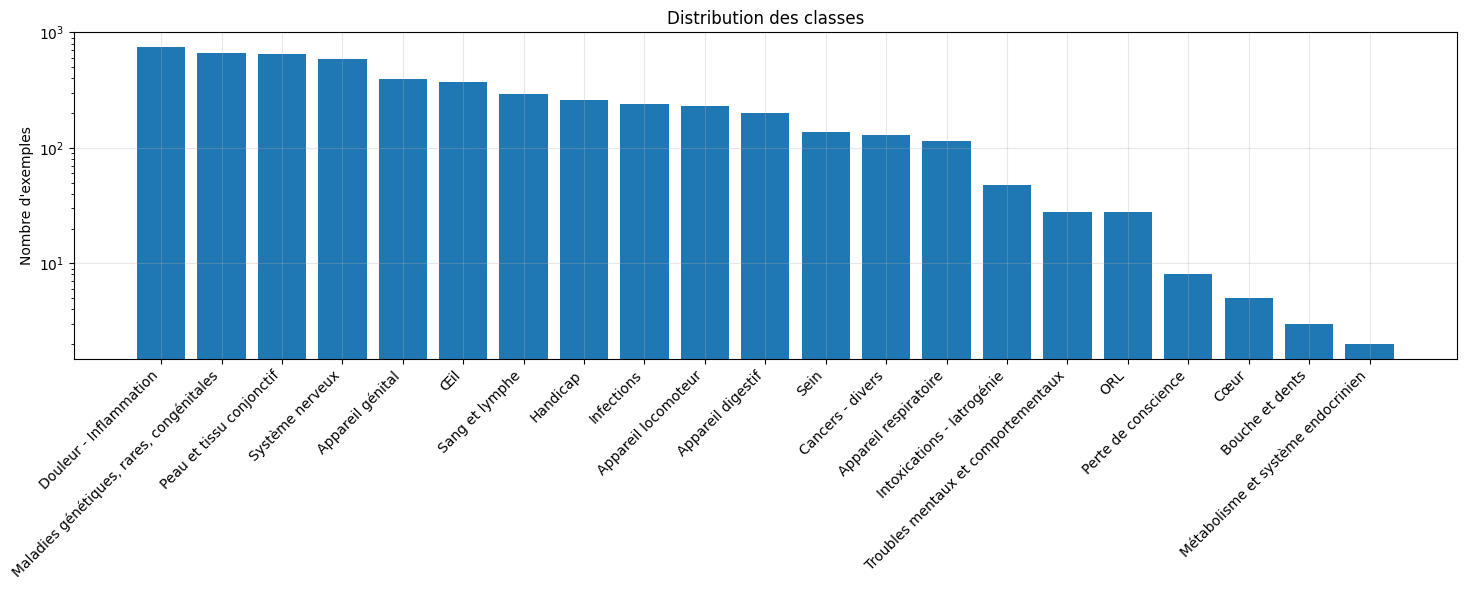

In [17]:
# Calcul du nombre de labels
labels_pd, counts_pd = extract_labels_counts(y_df, "categoriesThematiques")
# Affichage du graphe
plot_classes(labels_pd, counts_pd)

#### Notes : 

Nous remarquons que nous avons certaines classes qui sont réellement minoritaires dans le jeu de données. Nous avons décidé de réunir ces classes au sein d'une classe "éléments rares". Il s'agit des classes dont le count <10.

### Union des classes avec un effectif trop faible (inférieur à 10)

C:\Users\grani\AppData\Local\Temp\ipykernel_37688\1532278807.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_df["categories_regroupees"] = y_df["categoriesThematiques"].where(


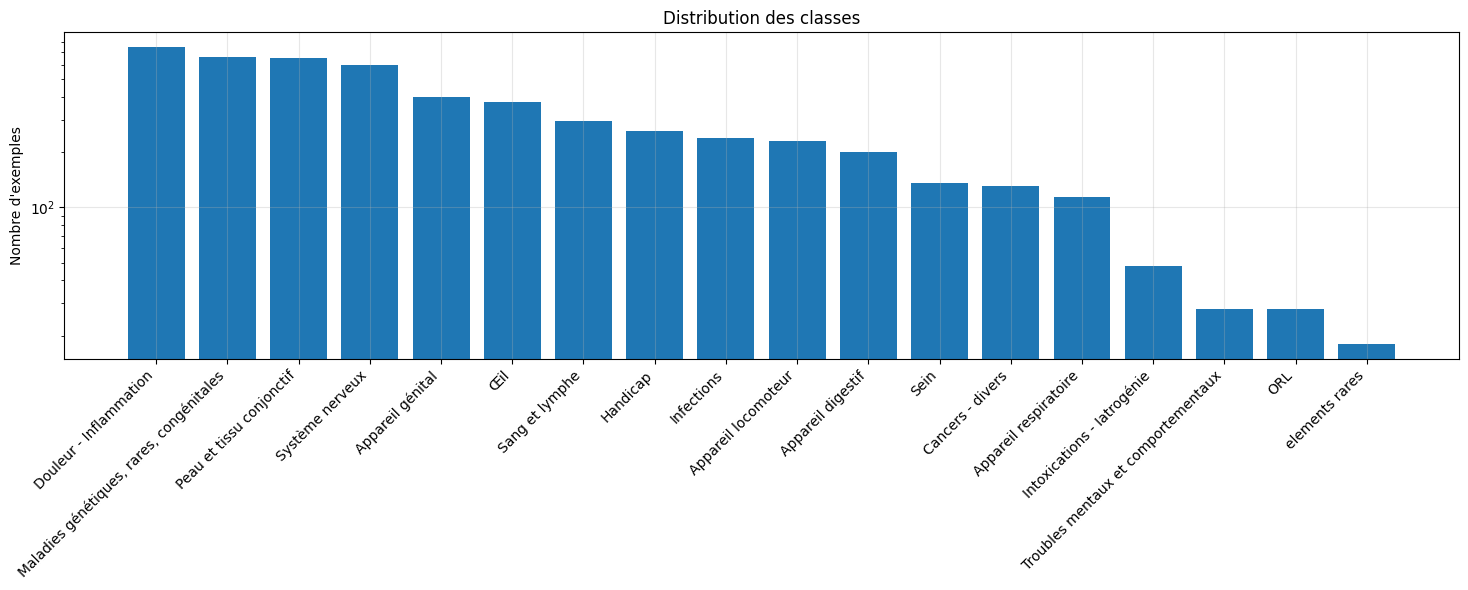

In [18]:
# Sélections des classes dont le cunt est inférieur à 10.
rare_labels = labels_pd[counts_pd < 10]
# Nouvelle colonne qui contient les nouvelles classes
y_df["categories_regroupees"] = y_df["categoriesThematiques"].where(
    ~y_df["categoriesThematiques"].isin(rare_labels), "elements rares")

# Calcul des counts des nouveaux labels
labels_rgp, counts_rgp = extract_labels_counts(y_df, "categories_regroupees")
# Affichage des valeurs
plot_classes(labels_rgp, counts_rgp)

# Partie 2 : Bag of Words

______

## 2.1. Traitement des variables

### a. Formatage du texte avec les fonctions de nettoyage

In [19]:
# Nettoyage des valeurs de X_df
X_df = X_df.map(clean_text)
X_df = X_df.fillna("")
# Création d'une nouvelle colonne qui contient les valeurs cibles
X_df["Texte"] = X_df["title"]+" "+ X_df["resumeSiteWeb"]
X_df.head(10)

,id,title,resumeSiteWeb,Texte
16,p 3193048,services d’aide et de soins à domicile accompa...,la has publie quatre guides à destination des ...,services d’aide et de soins à domicile accompa...
22,c 2964356,mettre en œuvre la conciliation des traitement...,la conciliation des traitements médicamenteux ...,mettre en œuvre la conciliation des traitement...
26,c 2833768,qualité de vie handicap les problèmes somatiqu...,les personnes handicapées sont susceptibles de...,qualité de vie handicap les problèmes somatiqu...
33,c 2772619,accueil accompagnement et organisation des soi...,ce guide à destination des professionnels de s...,accueil accompagnement et organisation des soi...
41,c 2634917,démarche d’assurance qualité des pratiques pro...,mesures échographiques de la clarté nucale et ...,démarche d’assurance qualité des pratiques pro...
64,c 1713137,choix méthodologiques pour le développement cl...,l’objectif de ce guide méthodologique est d’id...,choix méthodologiques pour le développement cl...
105,c 431300,méthode d’élaboration d’une démarche de soins ...,l’objectif de ce guide méthodologique est d ai...,méthode d’élaboration d’une démarche de soins ...
114,p 3324701,prise en charge thérapeutique curative et prév...,,prise en charge thérapeutique curative et prév...
115,p 3324692,prise en charge thérapeutique curative et prév...,,prise en charge thérapeutique curative et prév...
119,p 3321655,diagnostic et prise en charge de l’hypertonie ...,le glaucome est une maladie grave insidieuse e...,diagnostic et prise en charge de l’hypertonie ...


In [20]:
# Sélection des valeurs textes
X_final = X_df["Texte"].values
y_final = y_df["categories_regroupees"].values.reshape(-1)
# Affichage des 10 premières valeurs
print(X_final[:10])
print(y_final[:10])

['services d’aide et de soins à domicile accompagnement des personnes atteintes de maladie neurodégénérative la has publie quatre guides à destination des professionnels intervenant à domicile pour accompagner les personnes atteintes de maladie neurodégénérative il s agit en particulier de patients touchés par les maladies d’alzheimer de parkinson à corps de lewy ou concernés par des démences fronto temporales ou par la sclérose en plaques la has publie quatre guides à destination des professionnels intervenant à domicile pour accompagner les personnes atteintes de maladie neurodégénérative il s agit en particulier de patients touchés par les maladies d’alzheimer de parkinson à corps de lewy ou concernés par des démences fronto temporales ou par la sclérose en plaques'
 'mettre en œuvre la conciliation des traitements médicamenteux en cancérologie la conciliation des traitements médicamenteux en cancérologie complément au guide « mettre en oeuvre la conciliation des traitements médicam

### b. Encodage des valeurs cibles

In [21]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_final)
labels = le.classes_
print(labels)

['Appareil digestif' 'Appareil génital' 'Appareil locomoteur'
 'Appareil respiratoire' 'Cancers - divers' 'Douleur - Inflammation'
 'Handicap' 'Infections' 'Intoxications - Iatrogénie'
 'Maladies génétiques, rares, congénitales' 'ORL'
 'Peau et tissu conjonctif' 'Sang et lymphe' 'Sein' 'Système nerveux'
 'Troubles mentaux et comportementaux' 'elements rares' 'Œil']


### c. Séparation des ensembles de test et d'apprentissage

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_encoded, train_size=0.75, random_state = 42)
print(X_train.shape, X_test.shape)

(3865,) (1289,)


## 2.2 Modélisation - Count Vectorizer

### a. Définition des modèles

- Nous utilisons ici des modèles Logistic Regression, Linear SVC et Naïve Bayes.
- Le pipeline permet d'encoder correctement les valeurs sans commetre de fuite de données.

Nous utilisons comme encoder de texte CountVectorizer

In [23]:
pipe_LR = Pipeline([
    ("vectorizer", CountVectorizer(max_features=2000, min_df=5)),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe_SVC = Pipeline([
    ("vectorizer", CountVectorizer(max_features=2000, min_df=5)),
    ("clf", LinearSVC(random_state=0, tol=1e-5))
])

pipe_NB = Pipeline([
    ("vectorizer", CountVectorizer(max_features=2000, min_df=5)),
    ("clf", MultinomialNB())
])

### b. Evaluation des modèles

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4756
Score : 0.5089
              precision    recall  f1-score   support

           0       0.70      0.55      0.62        47
           1       0.49      0.38      0.43        89
           2       0.57      0.38      0.46        65
           3       0.92      0.61      0.73        36
           4       0.09      0.04      0.05        27
           5       0.56      0.56      0.56       193
           6       0.60      0.43      0.50        65
           7       0.85      0.51      0.64        55
           8       0.60      0.27      0.38        11
           9       0.65      0.61      0.63       155
          10       1.00      0.40      0.57         5
          11       0.44      0.53      0.48       156
          12       0.71      0.49      0.58        69
          13       0.83      0.51      0.63        37
          14       0.30      0.60      0.40       173
          15       0.50   

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

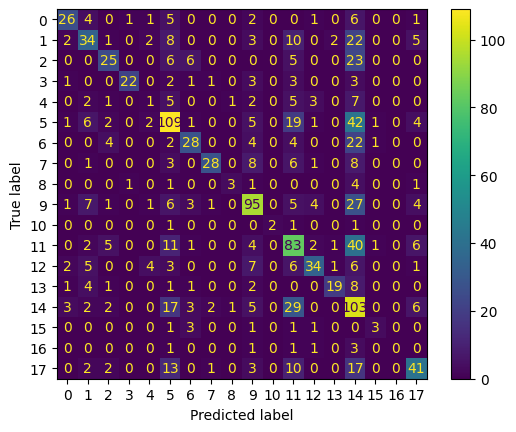

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4830
Score : 0.5120
              precision    recall  f1-score   support

           0       0.57      0.51      0.54        47
           1       0.55      0.38      0.45        89
           2       0.55      0.35      0.43        65
           3       0.85      0.61      0.71        36
           4       0.21      0.11      0.15        27
           5       0.61      0.56      0.58       193
           6       0.61      0.43      0.50        65
           7       0.83      0.62      0.71        55
           8       0.30      0.27      0.29        11
           9       0.66      0.60      0.63       155
          10       0.67      0.40      0.50         5
          11       0.43      0.52      0.47       156
          12       0.67      0.54      0.60        69
          13       0.74      0.54      0.62        37
          14       0.30      0.60      0.40       173
          15       0.33   

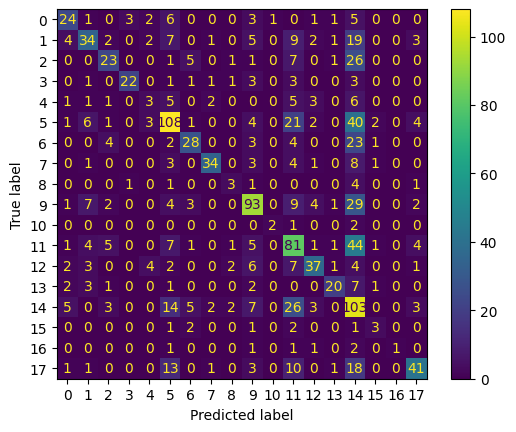

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4252
Score : 0.4585
              precision    recall  f1-score   support

           0       0.48      0.49      0.48        47
           1       0.54      0.17      0.26        89
           2       0.50      0.37      0.42        65
           3       0.87      0.56      0.68        36
           4       0.33      0.11      0.17        27
           5       0.34      0.68      0.45       193
           6       0.67      0.43      0.52        65
           7       0.68      0.35      0.46        55
           8       0.11      0.09      0.10        11
           9       0.63      0.50      0.56       155
          10       1.00      0.20      0.33         5
          11       0.33      0.58      0.42       156
          12       0.51      0.62      0.56        69
          13       0.94      0.41      0.57        37
          14       0.56      0.34      0.42       173
          15       0.45   

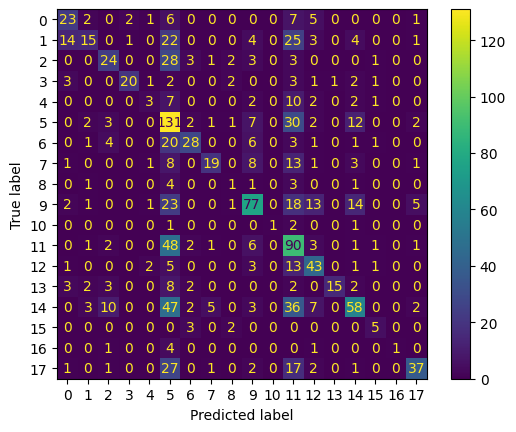

In [24]:
fit_et_evaluation_data_test(pipe_LR,X_train, X_test, y_train, y_test )

fit_et_evaluation_data_test(pipe_SVC,X_train, X_test, y_train, y_test )

fit_et_evaluation_data_test(pipe_NB,X_train, X_test, y_train, y_test )

#### _Commentaires sur les évaluations_

_A faire_


### c. Décompte des features utilisées par le modèles

Top 20 mots les plus frequents :
de : 34488
la : 17708
et : 12378
en : 10940
des : 10807
les : 10072
le : 8940
du : 8425
dans : 7227
un : 6369
une : 5876
par : 5491
au : 4255
pour : 3406
dépistage : 3332
ou : 3209
pas : 3088
est : 2806
remboursement : 2732
traitement : 2648


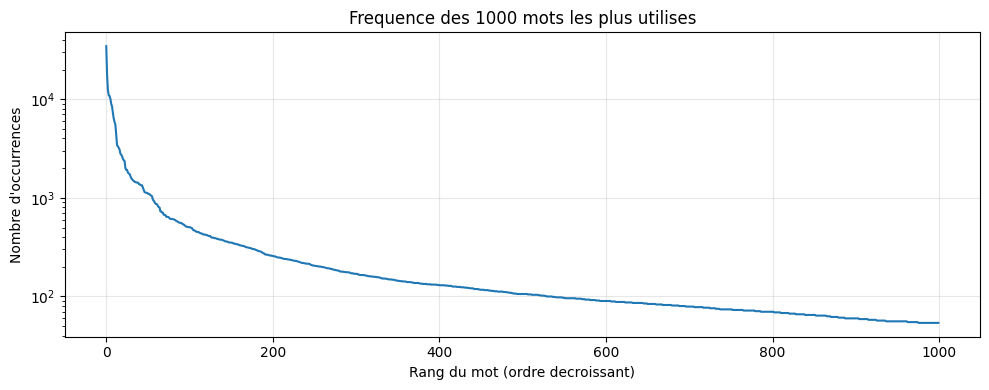

In [25]:
# Définition et ajustement de l'encodeur textuel
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X_final)

# --- Recuperation des mots et de leurs frequences globales ---
feature_names = vectorizer.get_feature_names_out()

# Somme des occurrences sur tous les documents
word_freq = np.asarray(X_vec.sum(axis=0)).ravel()

# --- Tri par frequence decroissante ---
top_n = 1000
top_idx = np.argsort(word_freq)[::-1][:top_n]

top_words = feature_names[top_idx]
top_freqs = word_freq[top_idx]

# --- Affichage des 20 mots les plus frequents ---
print("Top 20 mots les plus frequents :")
for w, f in zip(top_words[:20], top_freqs[:20]):
    print(f"{w} : {f}")

# --- Plot des 1000 mots les plus frequents ---
plt.figure(figsize=(10, 4))
plt.plot(top_freqs)
plt.yscale("log")
plt.title("Frequence des 1000 mots les plus utilises")
plt.xlabel("Rang du mot (ordre decroissant)")
plt.ylabel("Nombre d'occurrences")
plt.grid(True, alpha  =.3)
plt.tight_layout()
plt.show()

#### _Commentaires sur la figure_

_Nous remarquons que les mots les plus fréquents sont les déterminants, conjonctions, etc... Il s'agit donc de stop words qui nuisent à la performance du modèle. Il faut donc les retirer afin d'obtenir moins de signal venant de leur présence._

## 2.3 Modélisation - Count TfidfVectorizer

### a. Ajout des stops words dans le vocabulaire à supprimer

In [26]:
nltk.download("stopwords")
stopwords_fr = stopwords.words("french")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### b. Décompte du nombre de features utilisées par TF Vectorizer

Top 20 mots les plus importants (TF-IDF global) :
remboursement : 247.53
maintien : 238.44
mêmes : 232.45
conditions : 228.70
avis : 111.78
mise : 105.52
disposition : 105.25
traitement : 104.58
chlorhydrate : 100.92
charge : 97.88
prise : 97.73
thérapeutique : 91.89
progrès : 90.12
clinique : 86.88
rapport : 74.39
favorable : 67.81
chez : 67.37
patients : 65.60
soins : 60.14
démontré : 58.06


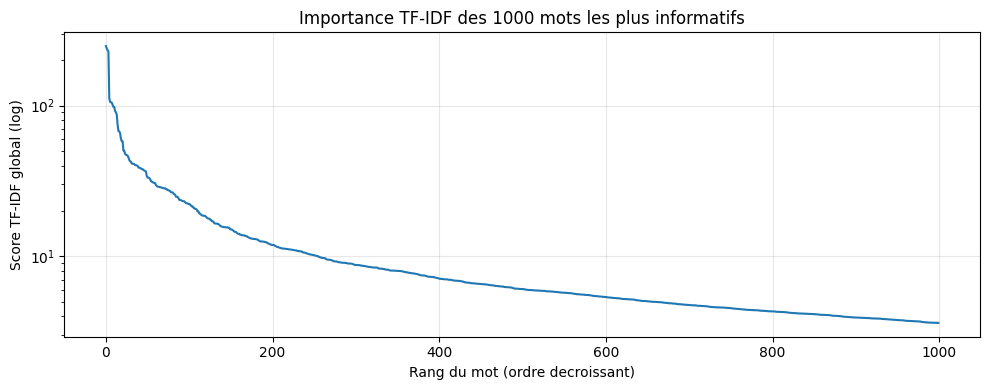

In [27]:
# Définition et ajustement de l'encodeur
vectorizer = TfidfVectorizer(stop_words=stopwords_fr, min_df=5,
    max_df=0.9, sublinear_tf=True)

X_tfidf = vectorizer.fit_transform(X_final)

# --- Recuperation des mots ---
feature_names = vectorizer.get_feature_names_out()

# --- Somme des poids TF-IDF ---
word_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()

# --- Tri par importance decroissante ---
top_n = 1000
top_idx = np.argsort(word_scores)[::-1][:top_n]

top_words = feature_names[top_idx]
top_scores = word_scores[top_idx]

# --- Affichage des 20 mots les plus importants ---
print("Top 20 mots les plus importants (TF-IDF global) :")
for w, s in zip(top_words[:20], top_scores[:20]):
    print(f"{w} : {s:.2f}")

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(top_scores)
plt.yscale("log")
plt.title("Importance TF-IDF des 1000 mots les plus informatifs")
plt.xlabel("Rang du mot (ordre decroissant)")
plt.ylabel("Score TF-IDF global (log)")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

#### _Commentaires sur la figure_

_Nous remarquons que les mots les plus fréquents sont les déterminants, conjonctions, etc... Il s'agit donc de stop words qui nuisent à la performance du modèle. Il faut donc les retirer afin d'obtenir moins de signal venant de leur présence._

### c. Définition des modèles

- Nous utilisons ici des modèles Logistic Regression, Linear SVC et Naïve Bayes.
- Le pipeline permet d'encoder correctement les valeurs sans commetre de fuite de données.

Nous utilisons comme encoder de texte CountVectorizer

In [28]:
# Classifier de type régression logistique
pipe_LR_tf = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words=stopwords_fr, min_df=1, max_df=0.9,sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000))
])
# Classifier de type SVM linéaire
pipe_SVC_tf = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words=stopwords_fr, min_df=1, max_df=0.9,sublinear_tf=True)),
    ("clf", LinearSVC(random_state=0, tol=1e-5))
])
# Classifier de type Pipeline
pipe_NB_tf = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words=stopwords_fr, min_df=5, max_df=0.9,sublinear_tf=True)),
    ("clf", MultinomialNB())
])

### d. Entrainement et évaluation des modèles

 _NB : Il n'a pas été jugé nécessaire de tester le modèle naïve Bayes car jugé comme sous performant face aur LR et au LSVC._

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5403
Score : 0.7044
              precision    recall  f1-score   support

           0       0.97      0.60      0.74        47
           1       0.77      0.69      0.73        89
           2       0.81      0.52      0.64        65
           3       0.91      0.56      0.69        36
           4       0.33      0.04      0.07        27
           5       0.64      0.87      0.74       193
           6       0.83      0.58      0.68        65
           7       0.98      0.78      0.87        55
           8       0.00      0.00      0.00        11
           9       0.65      0.79      0.72       155
          10       1.00      0.20      0.33         5
          11       0.53      0.84      0.65       156
          12       0.87      0.59      0.71        69
          13       0.94      0.43      0.59        37
          14       0.73      0.77      0.75       173
          15       0.00   

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

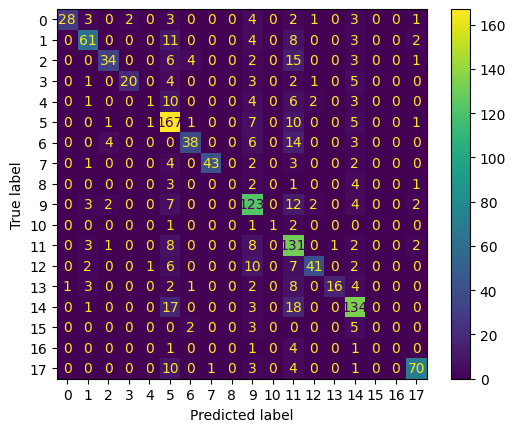

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.7075
Score : 0.7874
              precision    recall  f1-score   support

           0       0.88      0.74      0.80        47
           1       0.81      0.76      0.79        89
           2       0.75      0.62      0.68        65
           3       0.87      0.75      0.81        36
           4       0.53      0.37      0.43        27
           5       0.79      0.88      0.83       193
           6       0.82      0.72      0.77        65
           7       0.93      0.91      0.92        55
           8       0.45      0.45      0.45        11
           9       0.79      0.83      0.81       155
          10       0.75      0.60      0.67         5
          11       0.65      0.85      0.74       156
          12       0.82      0.65      0.73        69
          13       0.85      0.76      0.80        37
          14       0.86      0.83      0.85       173
          15       0.71   

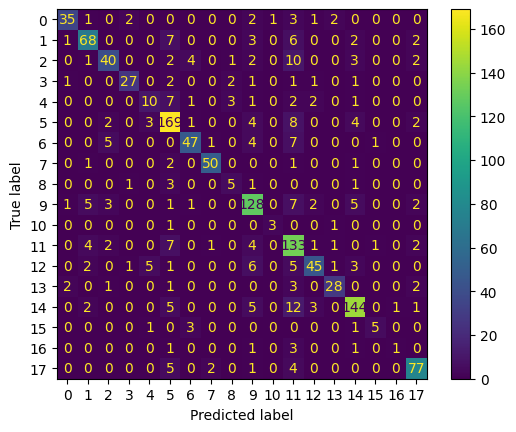

In [29]:
fit_et_evaluation_data_test(pipe_LR_tf,X_train, X_test, y_train, y_test )

fit_et_evaluation_data_test(pipe_SVC_tf,X_train, X_test, y_train, y_test )



#### Validation Croisée pour mesurer la robustesse

In [ ]:
print("="*30)
print('LR')
score_LR = crossvalidation_multi(pipe_LR,X_final, y_encoded)
print("="*30)
print('SVC')
score_SVC = crossvalidation_multi(pipe_SVC ,X_final, y_encoded)
print("="*30)
print('LR_tf')
score_LR_tf = crossvalidation_multi(pipe_LR_tf,X_final, y_encoded)
print("="*30)
print('SVC_tf')
score_SVC_tf = crossvalidation_multi(pipe_SVC_tf,X_final, y_encoded)

LR
  f1_macro: 0.470 ± 0.024
  f1_micro: 0.520 ± 0.013
  accuracy: 0.520 ± 0.013
SVC
  f1_macro: 0.470 ± 0.018
  f1_micro: 0.512 ± 0.009
  accuracy: 0.512 ± 0.009
LR_tf
  f1_macro: 0.553 ± 0.020
  f1_micro: 0.713 ± 0.004
  accuracy: 0.713 ± 0.004
SVC_tf
  f1_macro: 0.727 ± 0.026
  f1_micro: 0.798 ± 0.006
  accuracy: 0.798 ± 0.006


#### _Commentaires sur les résultats_

_Après entraintement, nous remarquons que les performances des modèles est supérieur par rapport à l'encodage réalisé par CountVectorize (F1 score LR 0.47<0.54 et LSVC 0.48<0.71). Ce résultat est cohérent dans la mesure où nous avons supprimé les stops words et de ce fait retirer du bruit dans les données. La validation croisée montre des résultats semblables entre différents plis._

____

# Partie 3 : Passage Deep Learning - Bert - Apprentissage des représentations de l'espace latent

____

## 3.1 Prétraitements

### a. Traitement de la donnée

#### i. Ajustement du texte pour correspondre au modèle

In [29]:
# Remplissage des valeurs manquantes par une chaîne de caractère vide
X_df_bert = X_df_bert.fillna("")
# Nettoyage des balises et du texte parasite
X_df_bert = X_df_bert.map(clean_text_bert)
# Union des colonnes titre et résumé avec l'ajout d'un séparateur sémantique compréhensible par le modèle
X_df_bert["Texte"] = X_df_bert["title"]+"</s>"+ X_df_bert["resumeSiteWeb"]
# Affichage de la première ligne du tableau
print(X_df_bert.values[0])

['p_3193048'
 'Services d’aide et de soins à domicile : accompagnement des personnes atteintes de maladie neurodégénérative'
 '{\' \': " La HAS publie quatre guides à destination des professionnels intervenant à domicile pour accompagner les personnes atteintes de maladie neurodégénérative. Il s\'agit en particulier de patients touchés par les maladies d’Alzheimer, de Parkinson, à Corps de Lewy ou concernés par des démences fronto-temporales ou par la sclérose en plaques. ", \' \': "La HAS publie quatre guides à destination des professionnels intervenant à domicile pour accompagner les personnes atteintes de maladie neurodégénérative. Il s\'agit en particulier de patients touchés par les maladies d’Alzheimer, de Parkinson, à Corps de Lewy ou concernés par des démences fronto-temporales ou par la sclérose en plaques.'
 'Services d’aide et de soins à domicile : accompagnement des personnes atteintes de maladie neurodégénérative</s>{\' \': " La HAS publie quatre guides à destination des p

#### ii. Extraction des features

In [30]:
# Extraction des textes d'entrées et formatage sous forme de list
X_bert =  list(X_df_bert["Texte"].values)

#### iii. Séparation des ensembles de test et d'apprentissage

In [44]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bert, y_final, random_state=45,  train_size=0.8)

#### iv. Encodage des variables cibles

In [45]:
le_b = LabelEncoder()
y_train_enc_b = le.fit_transform(y_train_b)
y_test_enc_b  = le.transform(y_test_b)

### b. Défintion du modèle de LLM utilisé

#### i. Import du modèle utilisé

In [46]:
# Défintion de l'appareil utilisé pour le traitement de l'apprentissage profond
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Définition du model CamemBert
tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModel.from_pretrained("camembert-base")
model.to(device)
# Défintion de l'inférence du modèle, nous ne sommes pas en phase d'apprentissage ici
model.eval()  


CamembertModel(
  (embeddings): CamembertEmbeddings(
    (word_embeddings): Embedding(32005, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): CamembertEncoder(
    (layer): ModuleList(
      (0-11): 12 x CamembertLayer(
        (attention): CamembertAttention(
          (self): CamembertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): CamembertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
     

#### ii. Définition de la classe d'embedder par Camembert

In [47]:
class CamembertEmbedder:
    def __init__(self, model_name="camembert-base", device=None, max_length=128, pooling="cls"):
        self.device = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
        self.max_length = max_length
        self.pooling = pooling

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def _pool(self, outputs, attention_mask):
        if self.pooling == "cls":
            return outputs.last_hidden_state[:, 0, :]
        elif self.pooling == "mean":
            mask = attention_mask.unsqueeze(-1)
            summed = (outputs.last_hidden_state * mask).sum(1)
            counts = mask.sum(1)
            return summed / counts
        else:
            raise ValueError("pooling must be 'cls' or 'mean'")

    def encode(self, texts, batch_size=16):
        embeddings = []

        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]

            enc = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            )

            enc = {k: v.to(self.device) for k, v in enc.items()}

            with torch.no_grad():
                outputs = self.model(**enc)

            emb = self._pool(outputs, enc["attention_mask"])
            embeddings.append(emb.cpu().numpy())

        return np.vstack(embeddings)


## 3.2 Création des embeddings

### a. Embedding via le jeton [CLS] en pooling

#### i. Entrainement et ajustement des embeddings

In [48]:
# Définition de l'objet avec pooling cls
embedder_cls = CamembertEmbedder(pooling="cls")

# Encodage de l'emsemble de test et d'apprentissage
X_train_emb = embedder_cls.encode(list(X_train_b))
print("X_train_b done")
X_test_emb  = embedder_cls.encode(list(X_test_b))

X_train_b done


#### ii. Visualisation des observations dans l'espace latent représenté en 3D

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


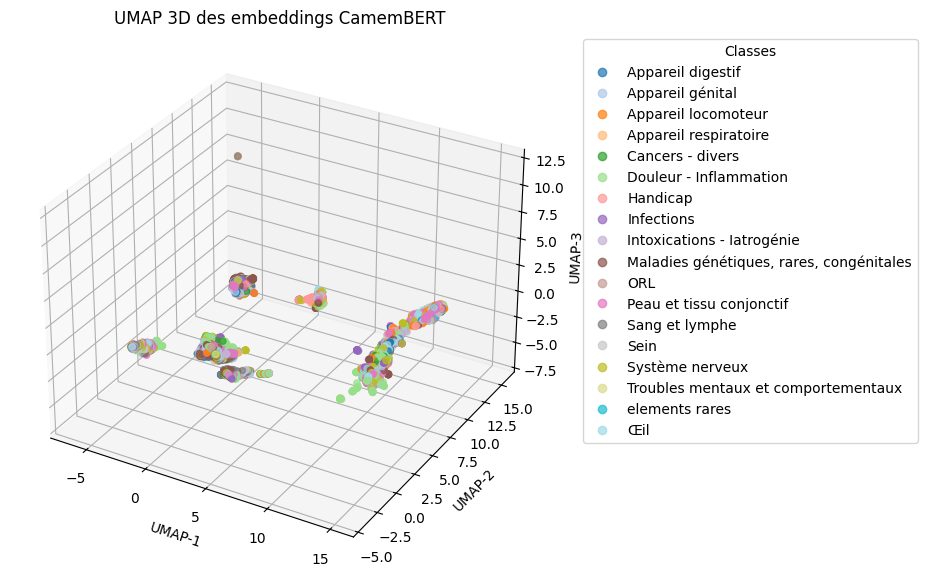

In [49]:
plot_umap_3D(X_train_emb, y_train_b)

### b. Embedding via le jeton le pooling moyen des jetons

#### i. Entrainement et ajustement des embeddings

In [50]:
# Définition de l'objet avec pooling mean
embedder_mean = CamembertEmbedder(pooling="mean")

# Encodage de l'emsemble de test et d'apprentissage
X_train_emb_mean = embedder_mean = CamembertEmbedder(pooling="mean").encode(list(X_train_b))
print("X_train_b done")
X_test_emb_mean  = embedder_mean = CamembertEmbedder(pooling="mean").encode(list(X_test_b))

X_train_b done


#### ii. Visualisation des observations dans l'espace latent représenté en 3D

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


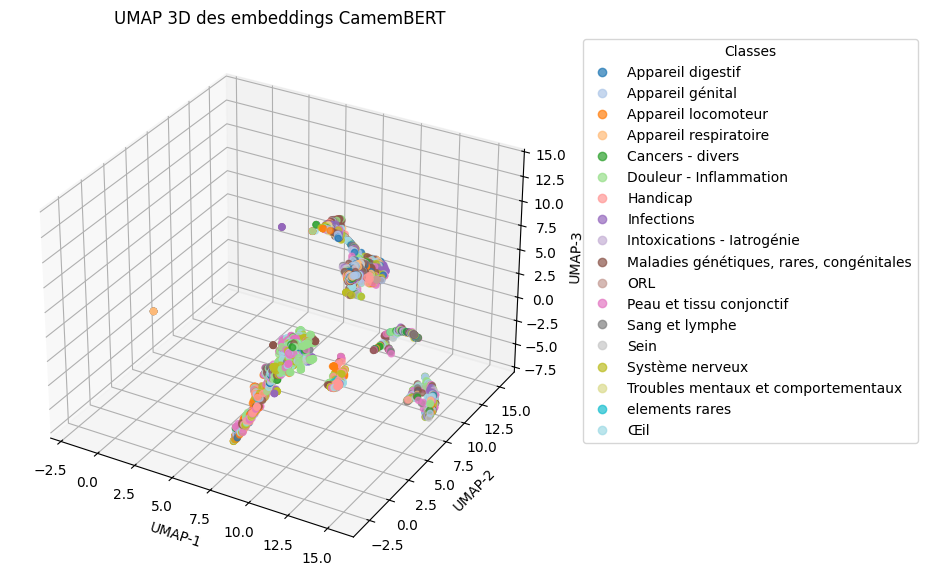

In [51]:
plot_umap_3D(X_train_emb_mean, y_train_b)

## 3.3 Classification des embeddings

### a. Définition des classifiers 

Logistic Regressor, Linear SVC et XGB Classifier (Regarder l'impact de sa performance)

In [52]:

LR = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

SVC = LinearSVC(random_state=0, tol=1e-5)

xgb_clf = XGBClassifier(
    objective="multi:softmax",   # multi-classes
    num_class=len(le.classes_),  # 18 classes
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

### b. Evaluation des classifieurs sur l'embedding CLS

#### i. Sans Scaler

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4285
Score : 0.5053
                                          precision    recall  f1-score   support

                       Appareil digestif       0.44      0.47      0.46        40
                        Appareil génital       0.47      0.28      0.35        68
                     Appareil locomoteur       0.35      0.66      0.45        44
                   Appareil respiratoire       0.45      0.89      0.60        19
                        Cancers - divers       0.18      0.38      0.24        24
                  Douleur - Inflammation       0.57      0.51      0.54       139
                                Handicap       0.58      0.54      0.56        52
                              Infections       0.67      0.75      0.70        51
              Intoxications - Iatrogénie       0.14      0.55      0.22        11
Maladies génétiques, rares, congénitales       0.74      0.62      0.6

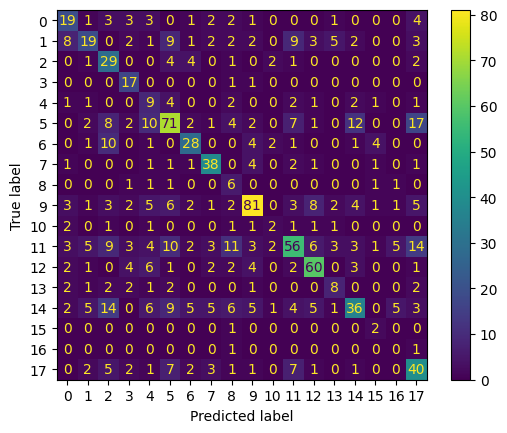

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5193
Score : 0.6072
                                          precision    recall  f1-score   support

                       Appareil digestif       0.73      0.47      0.58        40
                        Appareil génital       0.52      0.40      0.45        68
                     Appareil locomoteur       0.61      0.52      0.56        44
                   Appareil respiratoire       0.80      0.84      0.82        19
                        Cancers - divers       0.47      0.29      0.36        24
                  Douleur - Inflammation       0.52      0.71      0.60       139
                                Handicap       0.70      0.62      0.65        52
                              Infections       0.81      0.76      0.79        51
              Intoxications - Iatrogénie       0.50      0.09      0.15        11
Maladies génétiques, rares, congénitales       0.62      0.74      0.6

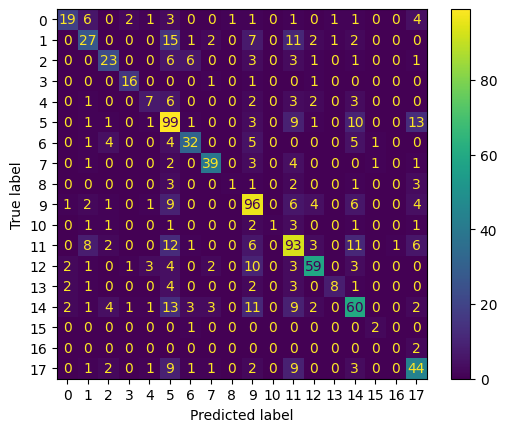

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5254
Score : 0.6353
              precision    recall  f1-score   support

           0       0.60      0.45      0.51        40
           1       0.55      0.44      0.49        68
           2       0.68      0.59      0.63        44
           3       0.94      0.79      0.86        19
           4       0.80      0.17      0.28        24
           5       0.59      0.79      0.67       139
           6       0.65      0.62      0.63        52
           7       0.85      0.69      0.76        51
           8       0.75      0.27      0.40        11
           9       0.62      0.78      0.69       130
          10       0.00      0.00      0.00        11
          11       0.61      0.69      0.65       143
          12       0.78      0.68      0.73        88
          13       0.89      0.38      0.53        21
          14       0.55      0.56      0.56       112
          15       0.50   

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

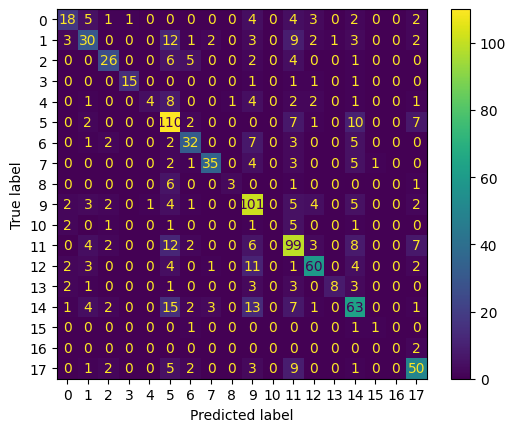

In [53]:
fit_et_evaluation_data_test(LR, X_train_emb, X_test_emb, y_train_b, y_test_b)

fit_et_evaluation_data_test(SVC, X_train_emb, X_test_emb, y_train_b, y_test_b)

fit_et_evaluation_data_test(xgb_clf, X_train_emb, X_test_emb, y_train_enc_b, y_test_enc_b)

#### _Commentaires sur les résultats_

_Les performances entre les différents modèles restent relativement similaires et pas excellentes (F1-Score <0.6). Toutefois, XGBoost et LinearSVC s'en sortent mieux que le logistic Regressor._

____

#### ii. Avec Scaler - Définition des pipelines

Nous noterons que le XGBClassifier n'a pas été retenu ici car il ne subit pas l'influence d'une distribution qui n'est pas normalisé, donc ce traitement n'apportait aucun gain de performance.

In [54]:
pipe_LR_B = Pipeline([("scaler", StandardScaler()),
                      ("LR", LogisticRegression(max_iter=2000, class_weight="balanced",
        n_jobs=-1 ))])

pipe_SVC_B = Pipeline([("scaler", StandardScaler()), ("L_SVC", LinearSVC(random_state=0, tol=1e-5))])

#### ii. Avec Scaler - Apprentissage et Evaluation 

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5181
Score : 0.6014
                                          precision    recall  f1-score   support

                       Appareil digestif       0.60      0.53      0.56        40
                        Appareil génital       0.45      0.53      0.49        68
                     Appareil locomoteur       0.60      0.55      0.57        44
                   Appareil respiratoire       0.58      0.79      0.67        19
                        Cancers - divers       0.26      0.42      0.32        24
                  Douleur - Inflammation       0.67      0.69      0.68       139
                                Handicap       0.59      0.65      0.62        52
                              Infections       0.81      0.75      0.78        51
              Intoxications - Iatrogénie       0.43      0.55      0.48        11
Maladies génétiques, rares, congénitales       0.62      0.65      0.6

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

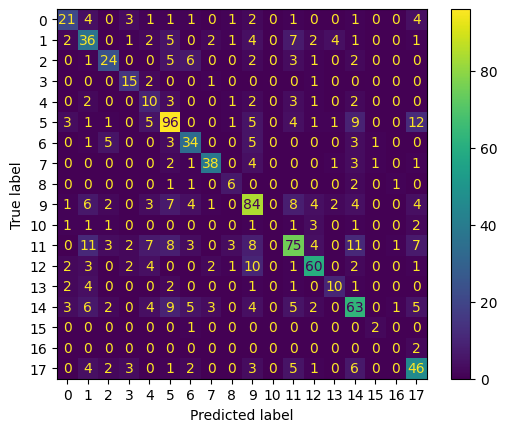

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4972
Score : 0.5742
                                          precision    recall  f1-score   support

                       Appareil digestif       0.73      0.47      0.58        40
                        Appareil génital       0.46      0.54      0.50        68
                     Appareil locomoteur       0.52      0.50      0.51        44
                   Appareil respiratoire       0.52      0.84      0.64        19
                        Cancers - divers       0.35      0.46      0.40        24
                  Douleur - Inflammation       0.63      0.68      0.66       139
                                Handicap       0.53      0.54      0.53        52
                              Infections       0.68      0.71      0.69        51
              Intoxications - Iatrogénie       0.33      0.27      0.30        11
Maladies génétiques, rares, congénitales       0.57      0.62      0.5

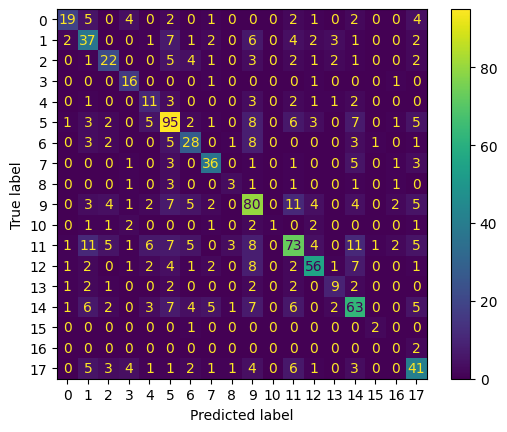

In [55]:
fit_et_evaluation_data_test(pipe_LR_B, X_train_emb, X_test_emb, y_train_b, y_test_b)

fit_et_evaluation_data_test(pipe_SVC_B, X_train_emb, X_test_emb, y_train_b, y_test_b)

#### _Commentaires sur les résultats_

_Avec le passage du StandardScaler, les performances entre le Logistic Regressor et le linear SVC restent relativement mauvaises et similaires sans scaler._

____


### c. Evaluation des classifieurs sur l'embedding mean

#### i. Apprentissage et Evaluation

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4137
Score : 0.4830
                                          precision    recall  f1-score   support

                       Appareil digestif       0.42      0.45      0.43        40
                        Appareil génital       0.43      0.26      0.33        68
                     Appareil locomoteur       0.42      0.59      0.49        44
                   Appareil respiratoire       0.38      0.84      0.52        19
                        Cancers - divers       0.17      0.33      0.23        24
                  Douleur - Inflammation       0.58      0.47      0.52       139
                                Handicap       0.46      0.56      0.50        52
                              Infections       0.63      0.75      0.68        51
              Intoxications - Iatrogénie       0.13      0.64      0.22        11
Maladies génétiques, rares, congénitales       0.70      0.55      0.6

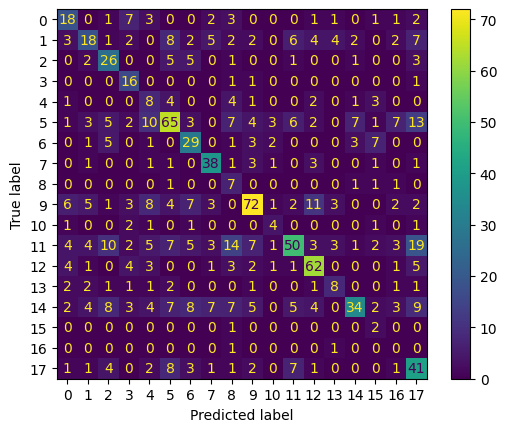

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5574
Score : 0.6334
                                          precision    recall  f1-score   support

                       Appareil digestif       0.67      0.60      0.63        40
                        Appareil génital       0.61      0.41      0.49        68
                     Appareil locomoteur       0.59      0.55      0.56        44
                   Appareil respiratoire       0.94      0.79      0.86        19
                        Cancers - divers       0.67      0.25      0.36        24
                  Douleur - Inflammation       0.55      0.76      0.64       139
                                Handicap       0.69      0.56      0.62        52
                              Infections       0.80      0.76      0.78        51
              Intoxications - Iatrogénie       0.60      0.27      0.38        11
Maladies génétiques, rares, congénitales       0.67      0.76      0.7

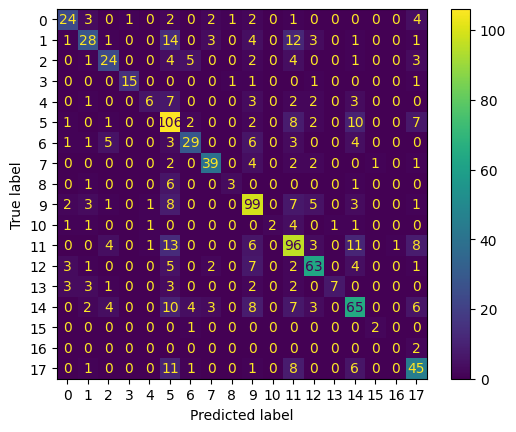

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5370
Score : 0.6353
              precision    recall  f1-score   support

           0       0.79      0.57      0.67        40
           1       0.53      0.50      0.52        68
           2       0.55      0.68      0.61        44
           3       0.88      0.74      0.80        19
           4       0.71      0.21      0.32        24
           5       0.58      0.79      0.67       139
           6       0.63      0.56      0.59        52
           7       0.83      0.69      0.75        51
           8       0.67      0.18      0.29        11
           9       0.67      0.78      0.72       130
          10       1.00      0.18      0.31        11
          11       0.59      0.64      0.62       143
          12       0.78      0.66      0.72        88
          13       0.88      0.33      0.48        21
          14       0.58      0.57      0.57       112
          15       0.50   

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

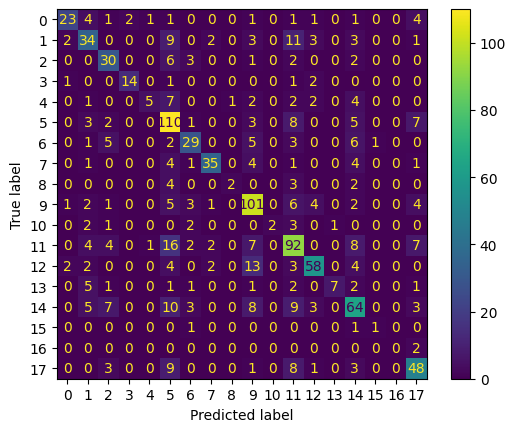

_____________________________________________
Essai sur echantillon de test
F1 macro : 0.5410
Score : 0.6159
                                          precision    recall  f1-score   support

                       Appareil digestif       0.56      0.50      0.53        40
                        Appareil génital       0.59      0.54      0.56        68
                     Appareil locomoteur       0.59      0.61      0.60        44
                   Appareil respiratoire       0.59      0.84      0.70        19
                        Cancers - divers       0.28      0.46      0.35        24
                  Douleur - Inflammation       0.67      0.65      0.66       139
                                Handicap       0.65      0.62      0.63        52
                              Infections       0.75      0.76      0.76        51
              Intoxications - Iatrogénie       0.45      0.45      0.45        11
Maladies génétiques, rares, congénitales       0.69      0.66      0.6

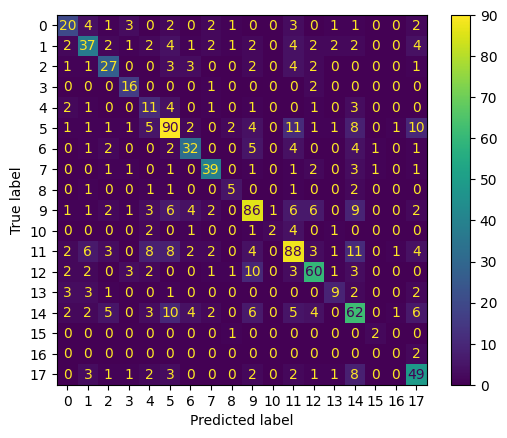

c:\Users\grani\anaconda3\envs\torch_NLP\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


_____________________________________________
Essai sur echantillon de test
F1 macro : 0.4918
Score : 0.5858
                                          precision    recall  f1-score   support

                       Appareil digestif       0.63      0.47      0.54        40
                        Appareil génital       0.54      0.53      0.53        68
                     Appareil locomoteur       0.63      0.61      0.62        44
                   Appareil respiratoire       0.63      0.89      0.74        19
                        Cancers - divers       0.27      0.29      0.28        24
                  Douleur - Inflammation       0.63      0.68      0.66       139
                                Handicap       0.62      0.50      0.55        52
                              Infections       0.71      0.67      0.69        51
              Intoxications - Iatrogénie       0.33      0.36      0.35        11
Maladies génétiques, rares, congénitales       0.65      0.62      0.6

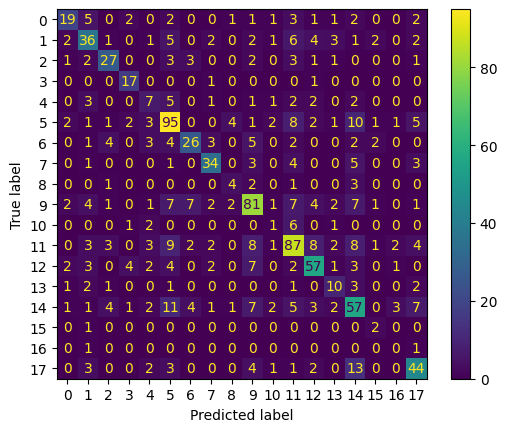

In [56]:
# Classifier sans Scaler
fit_et_evaluation_data_test(LR, X_train_emb_mean, X_test_emb_mean, y_train_b, y_test_b)

fit_et_evaluation_data_test(SVC, X_train_emb_mean, X_test_emb_mean, y_train_b, y_test_b)

fit_et_evaluation_data_test(xgb_clf, X_train_emb_mean, X_test_emb_mean, y_train_enc_b, y_test_enc_b)

# Classifier avec Scaler
fit_et_evaluation_data_test(pipe_LR_B, X_train_emb_mean, X_test_emb_mean, y_train_b, y_test_b)

fit_et_evaluation_data_test(pipe_SVC_B, X_train_emb_mean, X_test_emb_mean, y_train_b, y_test_b)

#### _Commentaires sur les résultats_

_Les résultats de cette partie sont relativement intéressant : XGBoost, LR Classifier avec le StandardScaler et Le linearSVC sans Scaler ont des performances similaires sur le F1-Score (~0.58). De futures investigations, notammenet avec de la validation croisée ou des K-plis pourrait rendre plus robustes ces résultats. Cette étape n'a pas été réalisée car trop coûteuse en temps de calcul pour k-plis._

____

# Partie 4 : Conclusion des résultats et pour aller plus loin

Ce notebook permet de voir une première approche de la classification de corpus de phrases médicales, à l'aide de méthode classique contre de nouvelles avec les LLM transformers. L'ensemble des méthodes révèlent qu'il s'agit d'un problème difficile à résoudre au vu des performances relativement faible par rapport à la tâche.

Toutefois, les approches de LLM sont sous exploités ici et un fine tuning pour notre tâche pourrait augmenter sensiblement la performance de nos modèles.
